# Prepare Monthly Rainfall For AOI From DE Africa S3

This notebook loads monthly CHIRPS rainfall for the selected AOI using the public Digital Earth Africa AWS S3 bucket. It does not require the DE Africa datacube, so it is suitable for Colab.

Source bucket details from the DE Africa CHIRPS data specification:

- bucket: `s3://deafrica-input-datasets/`
- region: `af-south-1`
- monthly product prefix: `rainfall_chirps_monthly/`

## Workflow

1. Mount Google Drive and locate `/content/drive/MyDrive/erw_spatial_mrv` when running in Colab.
2. Load `data/processed/boundaries/selected_districts_aoi.geojson` from notebook `01`.
3. Preview the AOI using `deafrica_tools.plotting.display_map` if it is available; otherwise fall back to a simple plot.
4. List public monthly CHIRPS GeoTIFFs from S3 using unsigned access.
5. Clip each monthly raster to the AOI, write AOI rasters, and summarize mean monthly rainfall for SCEPTER inputs.

In [18]:
from pathlib import Path
import os
import sys

try:
    from google.colab import drive

    drive.mount("/content/drive")
except ModuleNotFoundError:
    pass

LOCAL_PROJECT_ROOT = Path.cwd().resolve()
COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/erw_spatial_mrv")
COLAB_DATA_ROOT = COLAB_PROJECT_ROOT / "data"


def find_project_root(start: Path) -> Path:
    candidates = [LOCAL_PROJECT_ROOT, COLAB_PROJECT_ROOT]
    candidates.extend(start.resolve().parents)
    for candidate in candidates:
        if (candidate / "src" / "erw_mrv").exists():
            return candidate
    raise ModuleNotFoundError(
        "Could not find src/erw_mrv. In Colab, mount Google Drive and confirm "
        "the project is available at /content/drive/MyDrive/erw_spatial_mrv. "
        "Locally, run this notebook from the erw_spatial_mrv project."
    )


SOURCE_PROJECT_ROOT = find_project_root(LOCAL_PROJECT_ROOT)
PROJECT_ROOT = COLAB_PROJECT_ROOT if COLAB_DATA_ROOT.exists() else SOURCE_PROJECT_ROOT
DATA_ROOT = COLAB_DATA_ROOT if COLAB_DATA_ROOT.exists() else PROJECT_ROOT / "data"
os.environ["ERW_MRV_DATA_ROOT"] = str(DATA_ROOT)

SRC = SOURCE_PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SOURCE_PROJECT_ROOT = {SOURCE_PROJECT_ROOT}")
print(f"DATA_ROOT = {DATA_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/erw_spatial_mrv
SOURCE_PROJECT_ROOT = /content/drive/MyDrive/erw_spatial_mrv
DATA_ROOT = /content/drive/MyDrive/erw_spatial_mrv/data


In [19]:
def ensure_python_packages(packages):
    import importlib.util
    import subprocess

    missing = [pip_name for module_name, pip_name in packages if importlib.util.find_spec(module_name) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


ensure_python_packages([
    ("boto3", "boto3"),
    ("botocore", "botocore"),
])

In [20]:
import re
from datetime import datetime

import boto3
from botocore import UNSIGNED
from botocore.config import Config
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask

try:
    from deafrica_tools.plotting import display_map
except ModuleNotFoundError:
    display_map = None

## Configuration

In [21]:
START_DATE = "2026-01-01"
END_DATE = "2026-06-30"
ALLOW_PARTIAL_MONTHS = True

S3_BUCKET = "deafrica-input-datasets"
S3_REGION = "af-south-1"
S3_MONTHLY_PREFIX = "rainfall_chirps_monthly/"
S3_HTTPS_BASE = f"https://{S3_BUCKET}.s3.{S3_REGION}.amazonaws.com"

AOI_PATH = DATA_ROOT / "processed" / "boundaries" / "selected_districts_aoi.geojson"
RAINFALL_DIR = DATA_ROOT / "processed" / "climate" / "rainfall"
RASTER_DIR = RAINFALL_DIR / "rasters"
RAINFALL_DIR.mkdir(parents=True, exist_ok=True)
RASTER_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV = RAINFALL_DIR / "monthly_rainfall_aoi_jan_jun_2026.csv"
S3_INDEX_CSV = RAINFALL_DIR / "chirps_monthly_s3_index.csv"

if not AOI_PATH.exists():
    raise FileNotFoundError(
        f"AOI file not found: {AOI_PATH}. Run notebook 01 first so selected_districts_aoi.geojson exists."
    )

AOI_PATH

PosixPath('/content/drive/MyDrive/erw_spatial_mrv/data/processed/boundaries/selected_districts_aoi.geojson')

## Load And Display AOI

AOI bounds x=(30.39649360400017, 32.21209638100004), y=(0.162062292999963, 2.301767055000084)


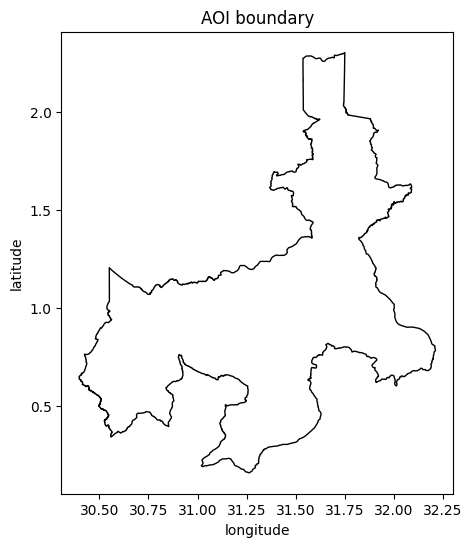

In [22]:
aoi = gpd.read_file(AOI_PATH).to_crs("EPSG:4326")
lon_min, lat_min, lon_max, lat_max = aoi.total_bounds
x = (float(lon_min), float(lon_max))
y = (float(lat_min), float(lat_max))

print(f"AOI bounds x={x}, y={y}")
if display_map is not None:
    display_map(x=x, y=y)
else:
    ax = aoi.plot(figsize=(7, 6), facecolor="none", edgecolor="black")
    ax.set_title("AOI boundary")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

## List Monthly CHIRPS Files From S3

In [23]:
def list_s3_keys(bucket: str, prefix: str) -> list[str]:
    s3 = boto3.client("s3", region_name=S3_REGION, config=Config(signature_version=UNSIGNED))
    paginator = s3.get_paginator("list_objects_v2")
    keys = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        keys.extend(item["Key"] for item in page.get("Contents", []))
    return keys


def month_from_key(key: str) -> pd.Period | None:
    patterns = [
        r"(?P<year>20\d{2})[._-](?P<month>0[1-9]|1[0-2])",
        r"(?P<year>20\d{2})/(?P<month>0[1-9]|1[0-2])",
    ]
    for pattern in patterns:
        match = re.search(pattern, key)
        if match:
            return pd.Period(f"{match.group('year')}-{match.group('month')}", freq="M")
    return None


start_month = pd.Period(pd.to_datetime(START_DATE), freq="M")
end_month = pd.Period(pd.to_datetime(END_DATE), freq="M")
target_months = pd.period_range(start_month, end_month, freq="M")

all_keys = list_s3_keys(S3_BUCKET, S3_MONTHLY_PREFIX)
tif_keys = [key for key in all_keys if key.lower().endswith((".tif", ".tiff"))]

records = []
for key in tif_keys:
    month = month_from_key(key)
    if month is not None and start_month <= month <= end_month:
        records.append({"month": str(month), "s3_key": key, "url": f"{S3_HTTPS_BASE}/{key}"})

s3_index = pd.DataFrame(records)
if s3_index.empty:
    raise FileNotFoundError(
        "Could not find any CHIRPS monthly S3 files for the requested period. "
        f"Inspect the bucket prefix {S3_MONTHLY_PREFIX} in {S3_BUCKET}."
    )

s3_index = s3_index.sort_values(["month", "s3_key"]).reset_index(drop=True)
s3_index.to_csv(S3_INDEX_CSV, index=False)

missing_months = sorted(set(str(month) for month in target_months) - set(s3_index["month"]))
if missing_months:
    message = (
        "Could not find CHIRPS monthly S3 files for: "
        f"{missing_months}. This often happens for the most recent month before the source product is published."
    )
    if ALLOW_PARTIAL_MONTHS:
        print(f"Warning: {message}")
        print("Continuing with available months only.")
    else:
        raise FileNotFoundError(f"{message} Inspect {S3_INDEX_CSV} or list the bucket prefix manually.")

s3_index

Continuing with available months only.


,month,s3_key,url
0,2026-01,rainfall_chirps_monthly/chirps-v2.0_2026.01.tif,https://deafrica-input-datasets.s3.af-south-1....
1,2026-02,rainfall_chirps_monthly/chirps-v2.0_2026.02.tif,https://deafrica-input-datasets.s3.af-south-1....
2,2026-03,rainfall_chirps_monthly/chirps-v2.0_2026.03.tif,https://deafrica-input-datasets.s3.af-south-1....
3,2026-04,rainfall_chirps_monthly/chirps-v2.0_2026.04.tif,https://deafrica-input-datasets.s3.af-south-1....
4,2026-05,rainfall_chirps_monthly/chirps-v2.0_2026.05.tif,https://deafrica-input-datasets.s3.af-south-1....


## Clip Rainfall Rasters To AOI

In [24]:
def clip_monthly_rainfall(row: pd.Series) -> dict:
    month = row["month"]
    output_path = RASTER_DIR / f"chirps_rainfall_{month.replace('-', '_')}.tif"

    if output_path.exists():
        with rasterio.open(output_path) as src:
            data = src.read(1, masked=True)
            rainfall_mm = float(data.mean())
        return {"month": month, "time": f"{month}-01", "rainfall_mm": rainfall_mm, "raster_path": str(output_path), "source_url": row["url"], "cached": True}

    with rasterio.open(row["url"]) as src:
        aoi_for_raster = aoi.to_crs(src.crs)
        clipped, transform = mask(src, aoi_for_raster.geometry, crop=True, nodata=src.nodata)
        profile = src.profile.copy()
        profile.update(
            height=clipped.shape[1],
            width=clipped.shape[2],
            transform=transform,
            compress="lzw",
        )

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(clipped)

    band = clipped[0]
    if profile.get("nodata") is not None:
        values = np.ma.masked_equal(band, profile["nodata"])
    else:
        values = np.ma.masked_invalid(band)
    rainfall_mm = float(values.mean())

    return {"month": month, "time": f"{month}-01", "rainfall_mm": rainfall_mm, "raster_path": str(output_path), "source_url": row["url"], "cached": False}


summaries = [clip_monthly_rainfall(row) for _, row in s3_index.groupby("month", as_index=False).first().iterrows()]
summary = pd.DataFrame(summaries).sort_values("month").reset_index(drop=True)
summary["product"] = "rainfall_chirps_monthly"
summary["bucket"] = S3_BUCKET
summary["region"] = S3_REGION
summary["aoi_path"] = str(AOI_PATH)
summary["requested_start_date"] = START_DATE
summary["requested_end_date"] = END_DATE
summary["missing_requested_months"] = ",".join(missing_months)
summary.to_csv(SUMMARY_CSV, index=False)

annualized_precip_mm_yr = summary["rainfall_mm"].sum() * (12 / len(summary))
print(f"Wrote monthly rainfall summary: {SUMMARY_CSV}")
print(f"Wrote monthly AOI rasters to: {RASTER_DIR}")
print(f"Period total rainfall: {summary['rainfall_mm'].sum():.1f} mm")
print(f"Annualized precipitation for SCEPTER defaults: {annualized_precip_mm_yr:.1f} mm/yr")
summary

Wrote monthly rainfall summary: /content/drive/MyDrive/erw_spatial_mrv/data/processed/climate/rainfall/monthly_rainfall_aoi_jan_jun_2026.csv
Wrote monthly AOI rasters to: /content/drive/MyDrive/erw_spatial_mrv/data/processed/climate/rainfall/rasters
Period total rainfall: 506.8 mm
Annualized precipitation for SCEPTER defaults: 1216.3 mm/yr


,month,time,rainfall_mm,raster_path,source_url,cached,product,bucket,region,aoi_path,requested_start_date,requested_end_date,missing_requested_months
0,2026-01,2026-01-01,29.299376,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,https://deafrica-input-datasets.s3.af-south-1....,True,rainfall_chirps_monthly,deafrica-input-datasets,af-south-1,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,2026-01-01,2026-06-30,2026-06
1,2026-02,2026-02-01,114.817745,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,https://deafrica-input-datasets.s3.af-south-1....,True,rainfall_chirps_monthly,deafrica-input-datasets,af-south-1,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,2026-01-01,2026-06-30,2026-06
2,2026-03,2026-03-01,125.934364,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,https://deafrica-input-datasets.s3.af-south-1....,True,rainfall_chirps_monthly,deafrica-input-datasets,af-south-1,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,2026-01-01,2026-06-30,2026-06
3,2026-04,2026-04-01,143.038605,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,https://deafrica-input-datasets.s3.af-south-1....,True,rainfall_chirps_monthly,deafrica-input-datasets,af-south-1,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,2026-01-01,2026-06-30,2026-06
4,2026-05,2026-05-01,93.700794,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,https://deafrica-input-datasets.s3.af-south-1....,True,rainfall_chirps_monthly,deafrica-input-datasets,af-south-1,/content/drive/MyDrive/erw_spatial_mrv/data/pr...,2026-01-01,2026-06-30,2026-06


## Plot Monthly Rainfall

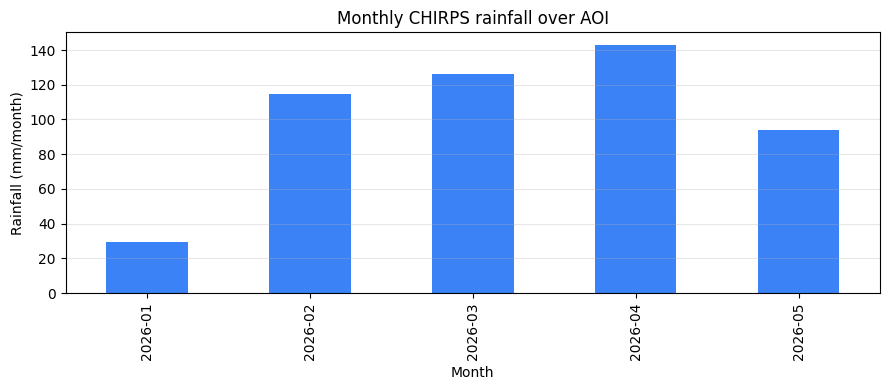

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
summary.plot.bar(x="month", y="rainfall_mm", ax=ax, legend=False, color="#3b82f6")
ax.set_ylabel("Rainfall (mm/month)")
ax.set_xlabel("Month")
ax.set_title("Monthly CHIRPS rainfall over AOI")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

## Preview First Month

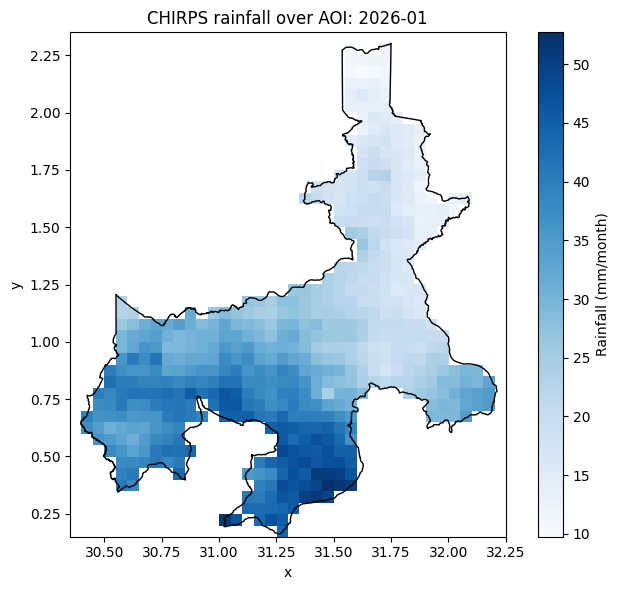

In [26]:
first = summary.iloc[0]
with rasterio.open(first["raster_path"]) as src:
    first_rainfall = src.read(1, masked=True)
    bounds = src.bounds

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(first_rainfall, cmap="Blues", extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
aoi.to_crs(src.crs).boundary.plot(ax=ax, color="black", linewidth=1)
fig.colorbar(im, ax=ax, label="Rainfall (mm/month)")
ax.set_title(f"CHIRPS rainfall over AOI: {first['month']}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()

## Outputs From This Notebook

This notebook writes rainfall outputs under `data/processed/climate/rainfall/`:

- `monthly_rainfall_aoi_jan_jun_2026.csv`: AOI mean monthly rainfall and source metadata.
- `chirps_monthly_s3_index.csv`: S3 objects selected for the requested months.
- `rasters/chirps_rainfall_YYYY_MM.tif`: monthly rainfall rasters clipped to the AOI.

For first-pass SCEPTER staging, use the printed annualized precipitation as `precipitation_mm_yr`, or use the monthly CSV if you later run season-aware scenarios.